<a href="https://colab.research.google.com/github/dhanushkumar-amk/BUILD-OWN-XYZ/blob/main/TF_IDF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Tokenizer**

In [1]:
import re

def tokenize(text):
    text = text.lower()
    tokens = re.findall(r"\w+|[^\w\s]", text)
    return tokens

# Test
print(tokenize("I love pizza!"))

['i', 'love', 'pizza', '!']


## **Term Frequency, as a proportion (Step 1)**

In [2]:
from collections import Counter

def compute_tf(document):
    tokens = tokenize(document)
    total_words = len(tokens)
    counts = Counter(tokens)

    tf = {word: count / total_words for word, count in counts.items()}
    return tf

# Test
doc = "the cat sat on the mat"
tf = compute_tf(doc)
for word, score in tf.items():
    print(f"{word}: {score:.3f}")

the: 0.333
cat: 0.167
sat: 0.167
on: 0.167
mat: 0.167


## **Document Frequency across the corpus (Step 2)**


In [3]:
def compute_df(corpus):
    df = Counter()
    for doc in corpus:
        unique_words = set(tokenize(doc))  # set = count each word once per doc
        for word in unique_words:
            df[word] += 1
    return df

# Test
corpus = [
    "the cat sat on the mat",
    "the dog ran in the park",
    "cats and dogs are pets",
    "I love my pet cat"
]

df = compute_df(corpus)
for word, count in df.items():
    print(f"{word}: DF = {count}")

mat: DF = 1
on: DF = 1
sat: DF = 1
cat: DF = 2
the: DF = 2
in: DF = 1
dog: DF = 1
ran: DF = 1
park: DF = 1
are: DF = 1
pets: DF = 1
cats: DF = 1
dogs: DF = 1
and: DF = 1
pet: DF = 1
my: DF = 1
love: DF = 1
i: DF = 1


## **Inverse Document Frequency with log + smoothing (Steps 3-4)**

In [4]:
import math

def compute_idf(corpus):
    df = compute_df(corpus)
    n_docs = len(corpus)

    idf = {}
    for word, doc_freq in df.items():
        # Smoothed version, avoids division/log(0) issues
        idf[word] = math.log((n_docs + 1) / (doc_freq + 1)) + 1

    return idf

# Test
idf = compute_idf(corpus)
for word, score in sorted(idf.items(), key=lambda x: x[1]):
    print(f"{word}: IDF = {score:.3f}")

cat: IDF = 1.511
the: IDF = 1.511
mat: IDF = 1.916
on: IDF = 1.916
sat: IDF = 1.916
in: IDF = 1.916
dog: IDF = 1.916
ran: IDF = 1.916
park: IDF = 1.916
are: IDF = 1.916
pets: IDF = 1.916
cats: IDF = 1.916
dogs: IDF = 1.916
and: IDF = 1.916
pet: IDF = 1.916
my: IDF = 1.916
love: IDF = 1.916
i: IDF = 1.916


## **Combine TF and IDF into TF-IDF scores for one document (Step 5)**

In [5]:
def compute_tfidf(document, idf):
    tf = compute_tf(document)
    tfidf = {}

    for word, tf_score in tf.items():
        idf_score = idf.get(word, 0)  # 0 if word never seen in training corpus
        tfidf[word] = tf_score * idf_score

    return tfidf

# Test
doc1 = corpus[0]
tfidf_doc1 = compute_tfidf(doc1, idf)

for word, score in sorted(tfidf_doc1.items(), key=lambda x: -x[1]):
    print(f"{word}: TF-IDF = {score:.4f}")

the: TF-IDF = 0.5036
sat: TF-IDF = 0.3194
on: TF-IDF = 0.3194
mat: TF-IDF = 0.3194
cat: TF-IDF = 0.2518


## **Build the full TF-IDF matrix (Step 6)**

In [6]:
def build_vocabulary(corpus):
    vocab_set = set()
    for doc in corpus:
        vocab_set.update(tokenize(doc))
    vocab_list = sorted(vocab_set)
    token_to_index = {token: idx for idx, token in enumerate(vocab_list)}
    return vocab_list, token_to_index

def build_tfidf_matrix(corpus):
    vocab_list, token_to_index = build_vocabulary(corpus)
    idf = compute_idf(corpus)

    matrix = []
    for doc in corpus:
        vector = [0.0] * len(vocab_list)
        tfidf_scores = compute_tfidf(doc, idf)

        for word, score in tfidf_scores.items():
            if word in token_to_index:
                position = token_to_index[word]
                vector[position] = score

        matrix.append(vector)

    return matrix, vocab_list

# Test
matrix, vocab_list = build_tfidf_matrix(corpus)

print("Vocabulary:", vocab_list)
for i, row in enumerate(matrix):
    rounded = [round(v, 3) for v in row]
    print(f"Doc {i}: {rounded}")

Vocabulary: ['and', 'are', 'cat', 'cats', 'dog', 'dogs', 'i', 'in', 'love', 'mat', 'my', 'on', 'park', 'pet', 'pets', 'ran', 'sat', 'the']
Doc 0: [0.0, 0.0, 0.252, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.319, 0.0, 0.319, 0.0, 0.0, 0.0, 0.0, 0.319, 0.504]
Doc 1: [0.0, 0.0, 0.0, 0.0, 0.319, 0.0, 0.0, 0.319, 0.0, 0.0, 0.0, 0.0, 0.319, 0.0, 0.0, 0.319, 0.0, 0.504]
Doc 2: [0.383, 0.383, 0.0, 0.383, 0.0, 0.383, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.383, 0.0, 0.0, 0.0]
Doc 3: [0.0, 0.0, 0.302, 0.0, 0.0, 0.0, 0.383, 0.0, 0.383, 0.0, 0.383, 0.0, 0.0, 0.383, 0.0, 0.0, 0.0, 0.0]


## **Compare a common word vs a rare word (Steps 7 + 8)**

In [7]:
# Build a bigger, more realistic test corpus
big_corpus = [
    "the cat sat on the mat",
    "the dog ran in the park",
    "the sun is bright today",
    "the weather is nice outside",
    "the coffee is hot this morning",
    "I love my pet cat very much",
    "margherita pizza is my favorite food"
]

big_idf = compute_idf(big_corpus)

print("IDF for a common word 'the':", round(big_idf.get("the", 0), 4))
print("IDF for a rare word 'margherita':", round(big_idf.get("margherita", 0), 4))

# Compare their TF-IDF scores in the documents they appear in
doc_common = "the cat sat on the mat"
doc_rare = "margherita pizza is my favorite food"

tfidf_common_doc = compute_tfidf(doc_common, big_idf)
tfidf_rare_doc = compute_tfidf(doc_rare, big_idf)

print("\nTF-IDF('the') in its document:", round(tfidf_common_doc.get("the", 0), 4))
print("TF-IDF('margherita') in its document:", round(tfidf_rare_doc.get("margherita", 0), 4))

IDF for a common word 'the': 1.2877
IDF for a rare word 'margherita': 2.3863

TF-IDF('the') in its document: 0.4292
TF-IDF('margherita') in its document: 0.3977


## **Cosine similarity (reuse from Bag-of-Words)**

In [8]:
def cosine_similarity(vec_a, vec_b):
    dot_product = sum(a * b for a, b in zip(vec_a, vec_b))
    magnitude_a = math.sqrt(sum(a * a for a in vec_a))
    magnitude_b = math.sqrt(sum(b * b for b in vec_b))

    if magnitude_a == 0 or magnitude_b == 0:
        return 0.0

    return dot_product / (magnitude_a * magnitude_b)

# Test with the original matrix
print("Pairwise TF-IDF similarities:")
for i in range(len(matrix)):
    for j in range(i + 1, len(matrix)):
        sim = cosine_similarity(matrix[i], matrix[j])
        print(f"Doc {i} vs Doc {j}: {sim:.3f}")

Pairwise TF-IDF similarities:
Doc 0 vs Doc 1: 0.395
Doc 0 vs Doc 2: 0.000
Doc 0 vs Doc 3: 0.117
Doc 1 vs Doc 2: 0.000
Doc 1 vs Doc 3: 0.000
Doc 2 vs Doc 3: 0.000


## **Direct comparison: TF-IDF vs Bag-of-Words similarity (Step 9)**

In [9]:
def build_bow_matrix(corpus):
    vocab_list, token_to_index = build_vocabulary(corpus)
    matrix = []
    for doc in corpus:
        vector = [0] * len(vocab_list)
        counts = Counter(tokenize(doc))
        for word, count in counts.items():
            if word in token_to_index:
                vector[token_to_index[word]] = count
        matrix.append(vector)
    return matrix

doc_cooking = "the recipe calls for the pan to be hot"
doc_basketball = "the player passed the ball to the guard"

compare_corpus = [doc_cooking, doc_basketball]

# Bag-of-Words version
bow_matrix = build_bow_matrix(compare_corpus)
bow_sim = cosine_similarity(bow_matrix[0], bow_matrix[1])

# TF-IDF version
tfidf_matrix, _ = build_tfidf_matrix(compare_corpus)
tfidf_sim = cosine_similarity(tfidf_matrix[0], tfidf_matrix[1])

print(f"Bag-of-Words similarity (cooking vs basketball): {bow_sim:.3f}")
print(f"TF-IDF similarity (cooking vs basketball):        {tfidf_sim:.3f}")
print("\nTF-IDF should show a LOWER similarity score, since it down-weights shared filler words like 'the' and 'to'")

Bag-of-Words similarity (cooking vs basketball): 0.564
TF-IDF similarity (cooking vs basketball):        0.403

TF-IDF should show a LOWER similarity score, since it down-weights shared filler words like 'the' and 'to'


## **— Demonstrate the remaining limitation: no synonym understanding (Step 10)**

In [10]:
doc_pizza = "I love pizza"
doc_pasta = "I love pasta"

limitation_corpus = [doc_pizza, doc_pasta]
limitation_matrix, limitation_vocab = build_tfidf_matrix(limitation_corpus)

sim = cosine_similarity(limitation_matrix[0], limitation_matrix[1])

print("Vocabulary:", limitation_vocab)
print(f"TF-IDF similarity between 'I love pizza' and 'I love pasta': {sim:.3f}")
print("\nEven though both are clearly about similar things (food, 'I love X'),")
print("TF-IDF has no concept that 'pizza' and 'pasta' are related — it only matches exact words.")
print("This is exactly the gap embeddings are built to close.")

Vocabulary: ['i', 'love', 'pasta', 'pizza']
TF-IDF similarity between 'I love pizza' and 'I love pasta': 0.503

Even though both are clearly about similar things (food, 'I love X'),
TF-IDF has no concept that 'pizza' and 'pasta' are related — it only matches exact words.
This is exactly the gap embeddings are built to close.


## **Heatmap of the TF-IDF matrix**

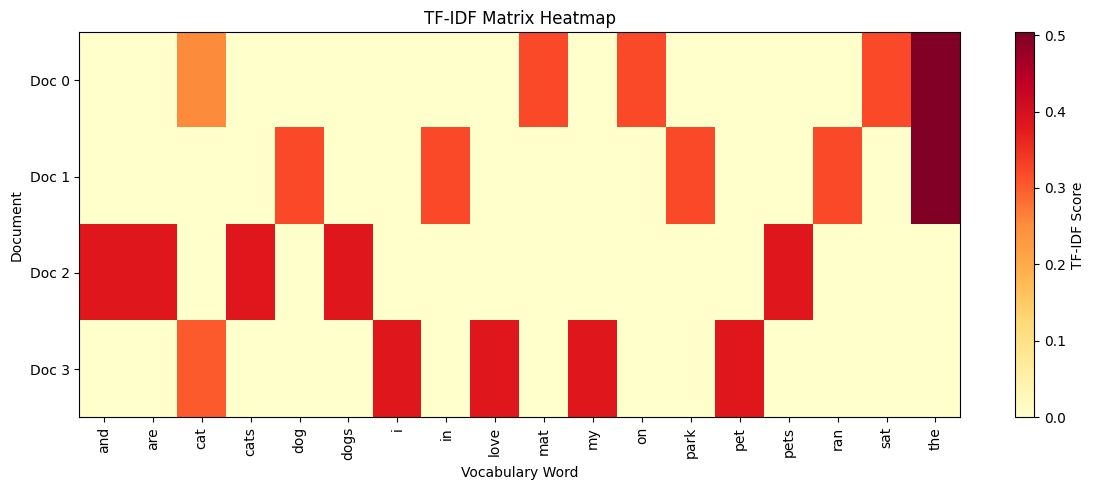

In [11]:
import matplotlib.pyplot as plt
import numpy as np

def plot_tfidf_heatmap(matrix, vocab_list, doc_labels=None):
    matrix_np = np.array(matrix)

    if doc_labels is None:
        doc_labels = [f"Doc {i}" for i in range(len(matrix))]

    fig, ax = plt.subplots(figsize=(12, 5))
    im = ax.imshow(matrix_np, cmap="YlOrRd", aspect="auto")

    ax.set_xticks(range(len(vocab_list)))
    ax.set_xticklabels(vocab_list, rotation=90)
    ax.set_yticks(range(len(doc_labels)))
    ax.set_yticklabels(doc_labels)

    ax.set_title("TF-IDF Matrix Heatmap")
    ax.set_xlabel("Vocabulary Word")
    ax.set_ylabel("Document")

    plt.colorbar(im, label="TF-IDF Score")
    plt.tight_layout()
    plt.show()

# Test with your original corpus/matrix
plot_tfidf_heatmap(matrix, vocab_list)

## **Bar chart: common word vs rare word IDF comparison**

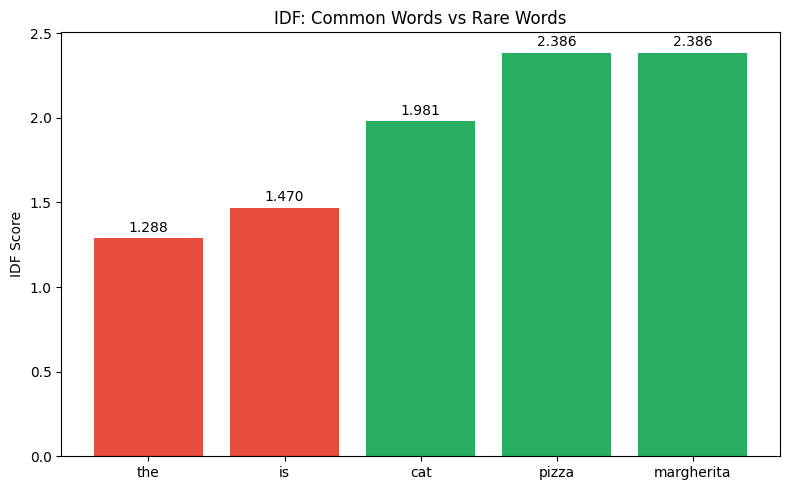

In [12]:
def plot_idf_comparison(idf_dict, words_to_compare):
    scores = [idf_dict.get(w, 0) for w in words_to_compare]

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(words_to_compare, scores, color=["#e74c3c" if s < 1.5 else "#27ae60" for s in scores])

    ax.set_ylabel("IDF Score")
    ax.set_title("IDF: Common Words vs Rare Words")

    for bar, score in zip(bars, scores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f"{score:.3f}", ha="center", va="bottom")

    plt.tight_layout()
    plt.show()

# Test — compare a common word against a rare word
plot_idf_comparison(big_idf, ["the", "is", "cat", "pizza", "margherita"])

## **Side-by-side: Bag-of-Words vs TF-IDF for the same document**

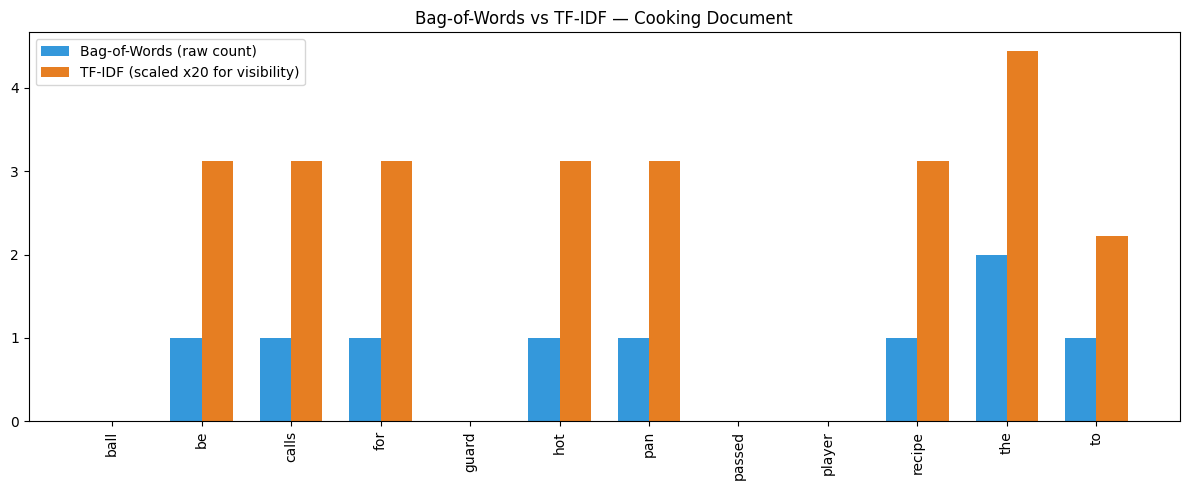

In [13]:
def plot_bow_vs_tfidf(bow_vector, tfidf_vector, vocab_list, doc_title="Document"):
    x = np.arange(len(vocab_list))
    width = 0.35

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(x - width/2, bow_vector, width, label="Bag-of-Words (raw count)", color="#3498db")
    ax.bar(x + width/2, [v * 20 for v in tfidf_vector], width, label="TF-IDF (scaled x20 for visibility)", color="#e67e22")

    ax.set_xticks(x)
    ax.set_xticklabels(vocab_list, rotation=90)
    ax.set_title(f"Bag-of-Words vs TF-IDF — {doc_title}")
    ax.legend()

    plt.tight_layout()
    plt.show()

# Test with the cooking document
bow_matrix_full = build_bow_matrix(compare_corpus)
tfidf_matrix_full, vocab_compare = build_tfidf_matrix(compare_corpus)

plot_bow_vs_tfidf(bow_matrix_full[0], tfidf_matrix_full[0], vocab_compare, doc_title="Cooking Document")